In [1]:
import pandas as pd
import random
from datetime import datetime, timedelta

data = []

facilities = ["Library", "Cafeteria", "Sports", "Hostel"]
years = ["1st", "2nd", "3rd", "4th"]
majors = ["CSE", "ECE", "MECH", "CIVIL"]

for i in range(500):
    row = {
        "student_id": i+1,
        "academic_year": random.choice(years),
        "major": random.choice(majors),
        "facility": random.choice(facilities),
        "satisfaction_score": random.randint(1,5),
        "timestamp": datetime.now() - timedelta(days=random.randint(0,365))
    }
    data.append(row)

df = pd.DataFrame(data)
df.to_csv("data.csv", index=False)

print("Dataset created!")

Dataset created!


In [2]:
import pandas as pd

df = pd.read_csv("../data/data.csv")
print(df.head())

   student_id academic_year  major   facility  satisfaction_score  \
0           1           1st   MECH  Cafeteria                   1   
1           2           4th  CIVIL  Cafeteria                   2   
2           3           4th    CSE  Cafeteria                   3   
3           4           4th    CSE     Sports                   3   
4           5           4th  CIVIL     Hostel                   5   

                    timestamp  
0  2025-12-29 10:24:41.660139  
1  2026-03-26 10:24:41.660139  
2  2025-11-24 10:24:41.660139  
3  2025-05-24 10:24:41.660139  
4  2025-12-06 10:24:41.660139  


In [4]:
df.dropna(inplace=True)
df["timestamp"] = pd.to_datetime(df["timestamp"])

In [5]:
df["category"] = df["satisfaction_score"].apply(
    lambda x: "Low" if x <= 2 else ("Medium" if x == 3 else "High")
)

In [7]:
overall_avg = df["satisfaction_score"].mean()

facility_avg = df.groupby("facility")["satisfaction_score"].mean()

highest = facility_avg.idxmax()
lowest = facility_avg.idxmin()

print(overall_avg, highest, lowest)

2.912 Cafeteria Sports


Matplotlib is building the font cache; this may take a moment.


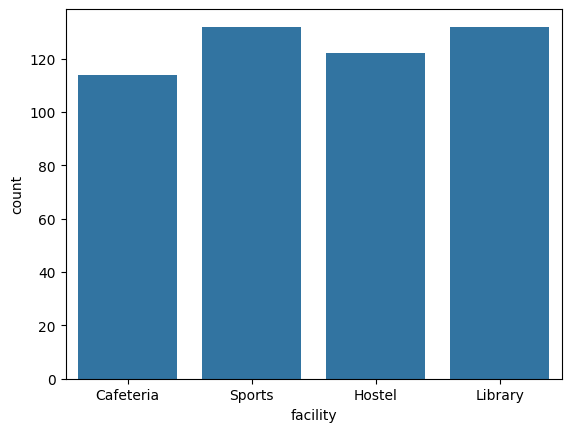

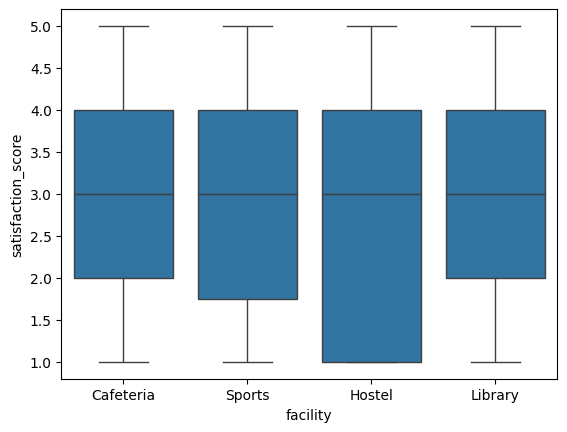

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x="facility", data=df)
plt.show()

sns.boxplot(x="facility", y="satisfaction_score", data=df)
plt.show()

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

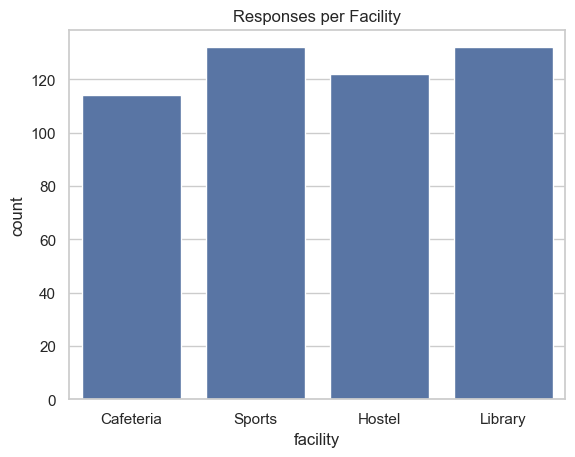

In [10]:
sns.countplot(x="facility", data=df)
plt.title("Responses per Facility")
plt.show()

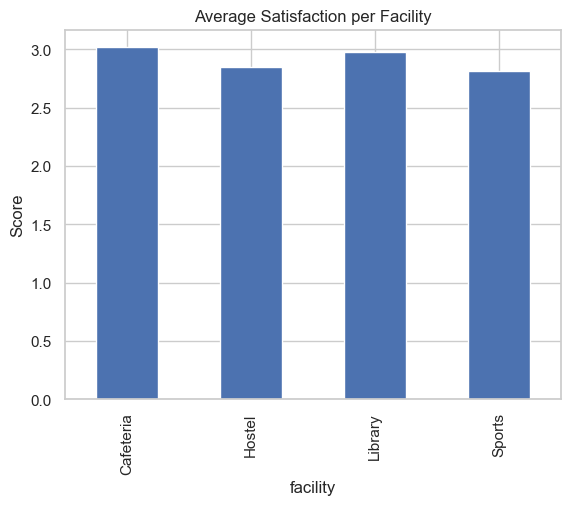

In [11]:
df.groupby("facility")["satisfaction_score"].mean().plot(kind="bar")
plt.title("Average Satisfaction per Facility")
plt.ylabel("Score")
plt.show()

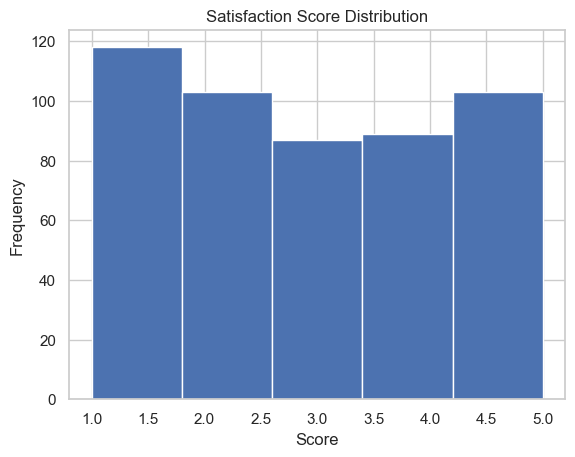

In [12]:
plt.hist(df["satisfaction_score"], bins=5)
plt.title("Satisfaction Score Distribution")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.show()

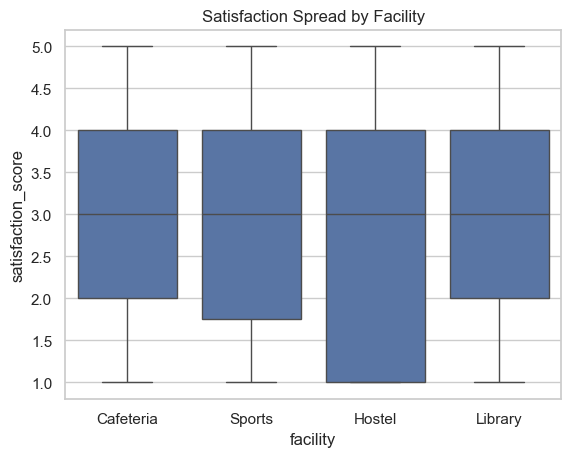

In [13]:
sns.boxplot(x="facility", y="satisfaction_score", data=df)
plt.title("Satisfaction Spread by Facility")
plt.show()

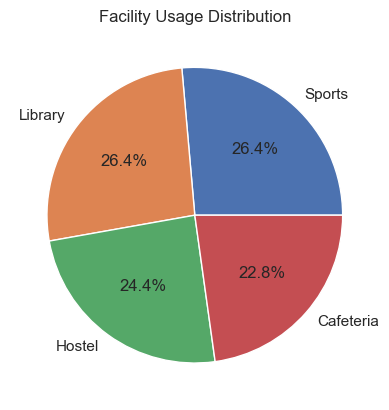

In [14]:
df["facility"].value_counts().plot(kind="pie", autopct='%1.1f%%')
plt.title("Facility Usage Distribution")
plt.ylabel("")
plt.show()

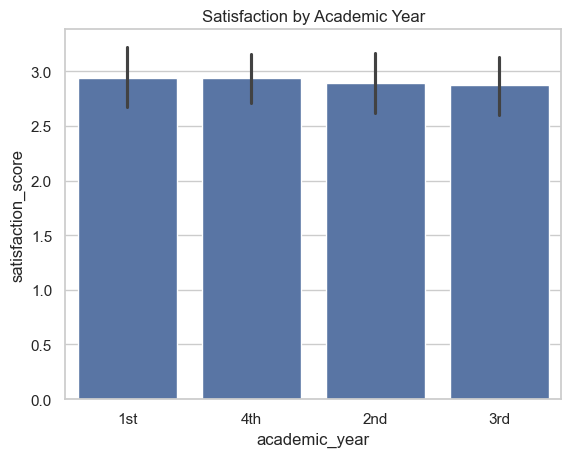

In [15]:
sns.barplot(x="academic_year", y="satisfaction_score", data=df)
plt.title("Satisfaction by Academic Year")
plt.show()

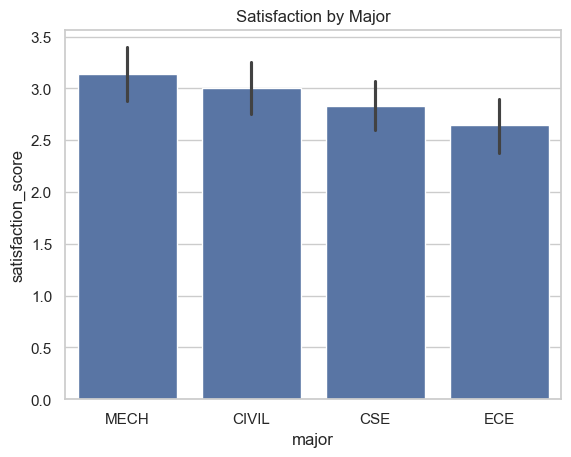

In [16]:
sns.barplot(x="major", y="satisfaction_score", data=df)
plt.title("Satisfaction by Major")
plt.show()